# Sink Node Characterisation — Which Nodes Become Sinks? (GRIT)

**Hypothesis H2:** Attention sinks preferentially form on structurally distinguished nodes.

We run inference on trained GRIT models to extract per-node sink scores
and correlate with degree, centrality, and spectral position.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import spearmanr
import yaml
import networkx as nx
from tqdm import tqdm
from torch_geometric.utils import degree, get_laplacian, to_scipy_sparse_matrix

from src.grit_model import InstrumentedGRIT
from src.datasets import get_dataloaders, DATASET_INFO
from src.metrics import compute_sink_scores

matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 150,
                             'axes.spines.top': False, 'axes.spines.right': False})

OUTPUTS_DIR = '../outputs'
FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
def load_experiment(experiment_id, device):
    config_path = os.path.join(OUTPUTS_DIR, experiment_id, 'config.yaml')
    with open(config_path) as f:
        config = yaml.safe_load(f)
    dataset_info = DATASET_INFO[config['data']['dataset']].copy()
    vnode_cfg = config.get('vnode', {})
    if vnode_cfg.get('enabled', False) and dataset_info.get('num_node_types') is not None:
        dataset_info['num_node_types'] = dataset_info['num_node_types'] + 1
        dataset_info['num_edge_types'] = dataset_info['num_edge_types'] + 1
    model = InstrumentedGRIT(config, dataset_info).to(device)
    model.load_state_dict(torch.load(
        os.path.join(OUTPUTS_DIR, experiment_id, 'best_model.pt'),
        map_location=device, weights_only=True))
    model.eval()
    return model, config, dataset_info

## 1. Extract per-node sink scores and structural properties

In [3]:
@torch.no_grad()
def extract_sink_data(model, config, device, max_graphs=200):
    _, _, test_loader, _ = get_dataloaders(config)
    model.eval()
    all_graphs = []
    graphs_done = 0
    for batch in tqdm(test_loader, desc='Extracting sink data'):
        if graphs_done >= max_graphs:
            break
        batch = batch.to(device)
        _ = model(batch, collect_diagnostics=True)
        batch_ids = model.layer_data[0]['batch']
        unique_graphs = batch_ids.unique()
        for g_idx, g_id in enumerate(unique_graphs):
            if graphs_done >= max_graphs:
                break
            graph_mask = (batch_ids == g_id)
            num_nodes_g = graph_mask.sum().item()
            node_indices = torch.where(graph_mask)[0]
            g_edges = batch.edge_index[:, batch.batch[batch.edge_index[0]] == g_id]
            local_map = {int(n): i for i, n in enumerate(node_indices)}
            local_edges = [[local_map[s], local_map[d]] for s, d in g_edges.t().tolist()
                           if s in local_map and d in local_map]
            local_ei = torch.tensor(local_edges).t() if local_edges else torch.zeros(2, 0, dtype=torch.long)
            local_src = local_ei[0] if local_ei.size(1) > 0 else torch.zeros(0, dtype=torch.long)
            deg = degree(local_src, num_nodes=num_nodes_g)
            if num_nodes_g > 2 and local_ei.size(1) > 0:
                ei_lap, ew_lap = get_laplacian(local_ei, normalization='sym', num_nodes=num_nodes_g)
                L = to_scipy_sparse_matrix(ei_lap, ew_lap, num_nodes=num_nodes_g).toarray()
                _, eigvecs = np.linalg.eigh(L)
                fiedler = eigvecs[:, 1]
            else:
                fiedler = np.zeros(num_nodes_g)
            G = nx.Graph()
            G.add_nodes_from(range(num_nodes_g))
            for s, d in zip(local_ei[0].tolist(), local_ei[1].tolist()):
                G.add_edge(s, d)
            centrality = nx.betweenness_centrality(G)
            cent_array = np.array([centrality.get(i, 0.0) for i in range(num_nodes_g)])
            graph_data = {'num_nodes': num_nodes_g, 'degree': deg.numpy(),
                          'fiedler': fiedler, 'centrality': cent_array,
                          'sink_scores_by_layer': {}}
            for layer_idx in range(len(model.attn_weights)):
                attn_full = model.attn_weights[layer_idx]
                if attn_full is not None and g_idx < attn_full.size(0):
                    attn_g = attn_full[g_idx, :, :num_nodes_g, :num_nodes_g]
                    sink_data = compute_sink_scores(attn_g)
                    graph_data['sink_scores_by_layer'][layer_idx + 1] = sink_data['sink_score_per_node'].numpy()
            all_graphs.append(graph_data)
            graphs_done += 1
    print(f'Collected data for {len(all_graphs)} graphs')
    return all_graphs

In [4]:
experiments_to_analyse = [
    ('zinc-grit', 'ZINC (no VNode, ~23 nodes)'),
    ('peptides-grit', 'Peptides (no VNode, ~150 nodes)'),
]

all_sink_data = {}
for eid, desc in experiments_to_analyse:
    if not os.path.exists(os.path.join(OUTPUTS_DIR, eid, 'best_model.pt')):
        print(f'Skipping {eid} — not trained yet')
        continue
    print(f'\n=== {desc} ===')
    model, config, _ = load_experiment(eid, device)
    all_sink_data[eid] = {'graphs': extract_sink_data(model, config, device),
                           'num_layers': model.num_layers, 'desc': desc}
    del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None


=== ZINC (no VNode, ~23 nodes) ===
  Precomputing rrwp(dim=21) for zinc/train...


Extracting data/ZINC/molecules.zip
Processing...
Processing test dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 10254.24it/s]
Done!
  train: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:23<00:00, 430.81it/s]


  Saved to data/pe_cache/zinc_train_rrwp21.pt
  Precomputing rrwp(dim=21) for zinc/val...


  val: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 433.04it/s]


  Saved to data/pe_cache/zinc_val_rrwp21.pt
  Precomputing rrwp(dim=21) for zinc/test...


  test: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 435.07it/s]


  Saved to data/pe_cache/zinc_test_rrwp21.pt


Extracting sink data:  22%|█████████████████████████████████▉                                                                                                                         | 7/32 [00:01<00:05,  4.86it/s]

Collected data for 200 graphs
Skipping peptides-grit — not trained yet


## 2. Sink Score vs Structural Properties

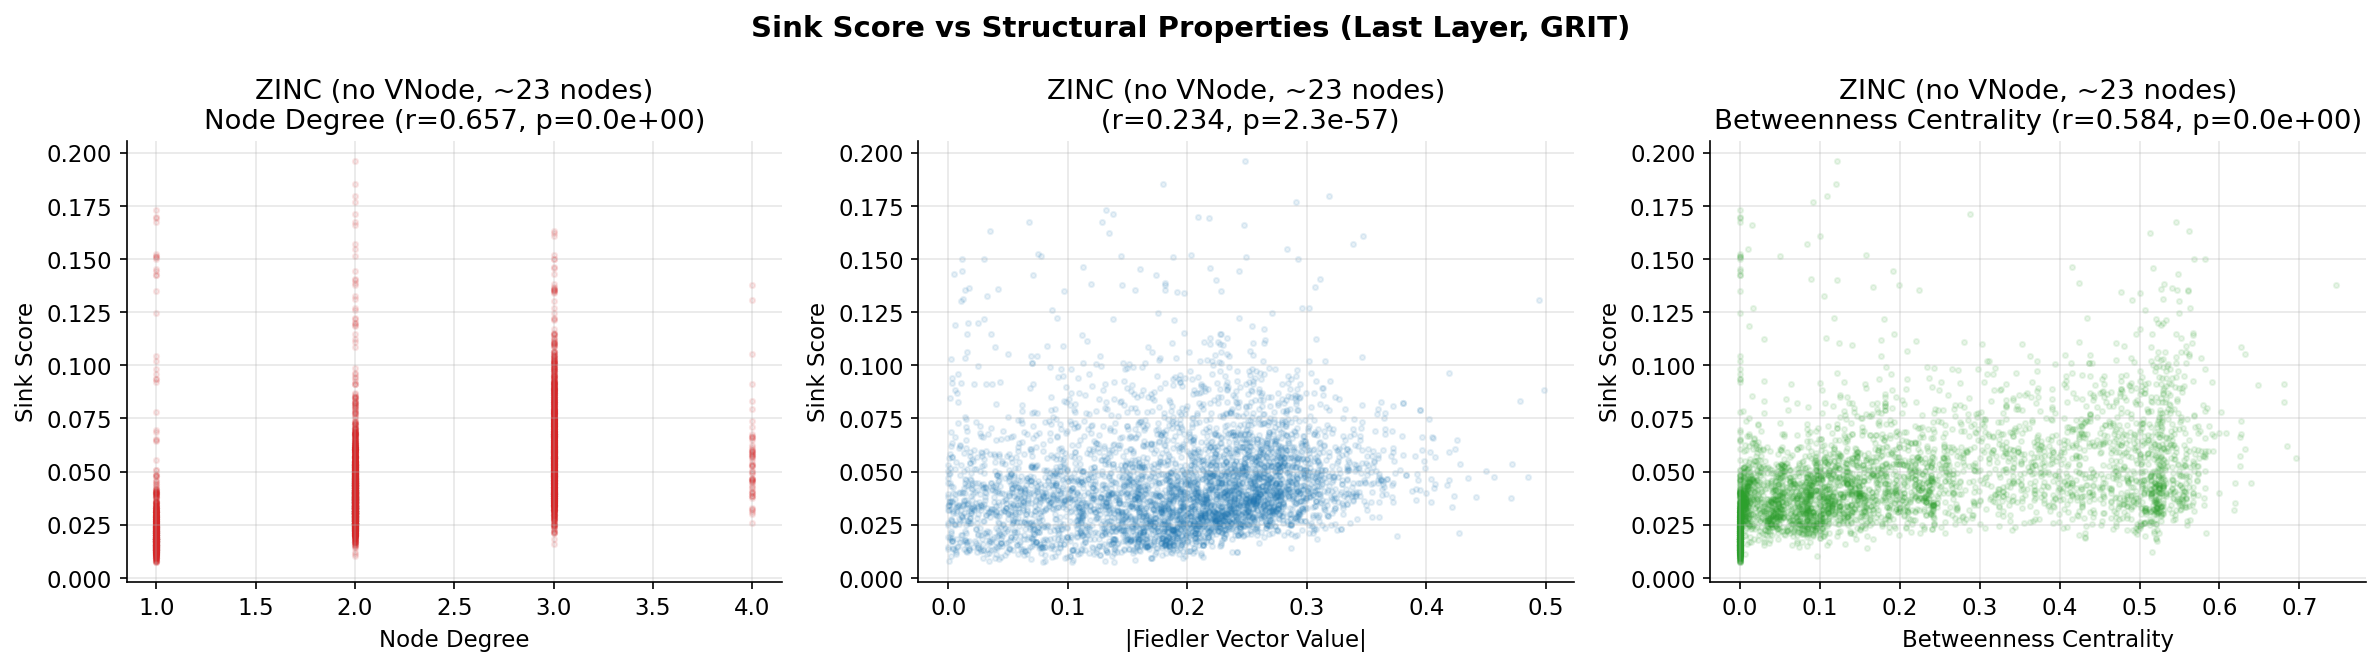

In [5]:
n_rows = len(all_sink_data)
if n_rows == 0:
    print('No data available yet.')
else:
    fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4.5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    for row, (eid, data) in enumerate(all_sink_data.items()):
        graphs = data['graphs']
        last_layer = data['num_layers']
        desc = data['desc']
        degrees, sink_scores = [], []
        fiedler_vals, sink_scores_f = [], []
        cent_vals, sink_scores_c = [], []
        for g in graphs:
            if last_layer not in g['sink_scores_by_layer']:
                continue
            scores = g['sink_scores_by_layer'][last_layer]
            degrees.extend(g['degree'].tolist())
            sink_scores.extend(scores.tolist())
            fiedler_vals.extend(np.abs(g['fiedler']).tolist())
            sink_scores_f.extend(scores.tolist())
            cent_vals.extend(g['centrality'].tolist())
            sink_scores_c.extend(scores.tolist())
        for col, (xvals, yvals, xlabel, color) in enumerate([
            (degrees, sink_scores, 'Node Degree', 'tab:red'),
            (fiedler_vals, sink_scores_f, '|Fiedler Vector Value|', 'tab:blue'),
            (cent_vals, sink_scores_c, 'Betweenness Centrality', 'tab:green')]):
            xvals, yvals = np.array(xvals), np.array(yvals)
            r, p = spearmanr(xvals, yvals)
            axes[row, col].scatter(xvals, yvals, alpha=0.1, s=6, color=color)
            axes[row, col].set_xlabel(xlabel)
            axes[row, col].set_ylabel('Sink Score')
            axes[row, col].set_title(f'{desc}\n{xlabel.split("|")[0].strip()} (r={r:.3f}, p={p:.1e})')
            axes[row, col].grid(True, alpha=0.3)
    plt.suptitle('Sink Score vs Structural Properties (Last Layer, GRIT)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'fig5_sink_characterisation.pdf'), bbox_inches='tight', dpi=150)
    plt.show()

## 3. Is the sink node the max-degree / max-centrality node?

In [6]:
for eid, data in all_sink_data.items():
    graphs = data['graphs']
    last_layer = data['num_layers']
    sink_max_deg, sink_top3, sink_max_cent, total = 0, 0, 0, 0
    for g in graphs:
        if last_layer not in g['sink_scores_by_layer']:
            continue
        scores = g['sink_scores_by_layer'][last_layer]
        sink_node = np.argmax(scores)
        total += 1
        deg_rank = int((g['degree'] >= g['degree'][sink_node]).sum())
        if deg_rank == 1: sink_max_deg += 1
        if deg_rank <= 3: sink_top3 += 1
        cent_rank = int((g['centrality'] >= g['centrality'][sink_node]).sum())
        if cent_rank == 1: sink_max_cent += 1
    print(f'\n=== {data["desc"]} ({total} graphs) ===')
    print(f'  Sink = max-degree:     {sink_max_deg:>4}/{total} ({100*sink_max_deg/total:.1f}%)')
    print(f'  Sink = top-3 degree:   {sink_top3:>4}/{total} ({100*sink_top3/total:.1f}%)')
    print(f'  Sink = max-centrality: {sink_max_cent:>4}/{total} ({100*sink_max_cent/total:.1f}%)')


=== ZINC (no VNode, ~23 nodes) (200 graphs) ===
  Sink = max-degree:        1/200 (0.5%)
  Sink = top-3 degree:      3/200 (1.5%)
  Sink = max-centrality:   20/200 (10.0%)


## 4. Sink stability across layers and dominance

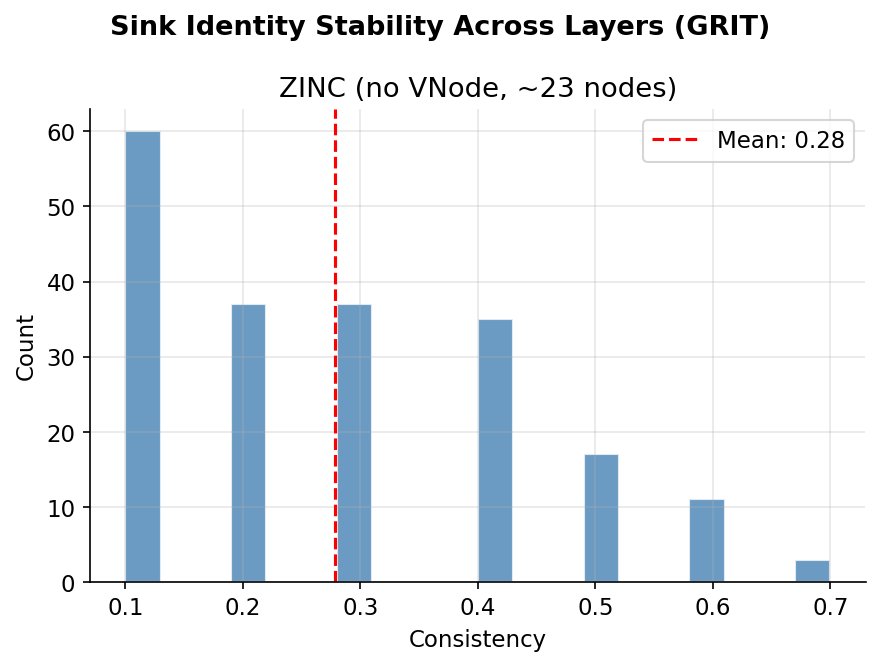

In [7]:
n_exps = len(all_sink_data)
if n_exps > 0:
    fig, axes = plt.subplots(1, n_exps, figsize=(6 * n_exps, 4.5))
    if n_exps == 1: axes = [axes]
    for ax, (eid, data) in zip(axes, all_sink_data.items()):
        consistency_scores = []
        for g in data['graphs']:
            sink_nodes = [np.argmax(g['sink_scores_by_layer'][l])
                          for l in sorted(g['sink_scores_by_layer'].keys())]
            if len(sink_nodes) > 1:
                final = sink_nodes[-1]
                consistency_scores.append(np.mean([1.0 if s == final else 0.0 for s in sink_nodes]))
        ax.hist(consistency_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
        ax.axvline(np.mean(consistency_scores), color='red', linestyle='--',
                   label=f'Mean: {np.mean(consistency_scores):.2f}')
        ax.set_xlabel('Consistency')
        ax.set_ylabel('Count')
        ax.set_title(data['desc'])
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Sink Identity Stability Across Layers (GRIT)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'fig6_sink_stability.pdf'), bbox_inches='tight', dpi=150)
    plt.show()

## 5. VNode absorption check

In [9]:
vnode_experiments = [
    ('zinc-grit-vnode', 'ZINC with VNode'),
]
for eid, desc in vnode_experiments:
    if not os.path.exists(os.path.join(OUTPUTS_DIR, eid, 'best_model.pt')):
        print(f'Skipping {eid} — not trained yet')
        continue
    print(f'\n=== {desc} ===')
    model, config, _ = load_experiment(eid, device)
    vnode_graphs = extract_sink_data(model, config, device, max_graphs=100)
    last_layer = model.num_layers
    vnode_is_sink, total = 0, 0
    vnode_sink_scores = []
    for g in vnode_graphs:
        if last_layer not in g['sink_scores_by_layer']:
            continue
        scores = g['sink_scores_by_layer'][last_layer]
        total += 1
        vnode_idx = g['num_nodes'] - 1
        if np.argmax(scores) == vnode_idx:
            vnode_is_sink += 1
        if vnode_idx < len(scores):
            vnode_sink_scores.append(scores[vnode_idx])
    print(f'  VNode is sink: {vnode_is_sink}/{total} ({100*vnode_is_sink/total:.1f}%)')
    print(f'  VNode avg sink score: {np.mean(vnode_sink_scores):.4f}')
    del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None


=== ZINC with VNode ===
  Loading cached PE for zinc/train from data/pe_cache/zinc_train_rrwp21.pt
  Loading cached PE for zinc/val from data/pe_cache/zinc_val_rrwp21.pt
  Loading cached PE for zinc/test from data/pe_cache/zinc_test_rrwp21.pt


Extracting sink data:  12%|███████████████████▍                                                                                                                                       | 4/32 [00:00<00:05,  5.03it/s]


Collected data for 100 graphs
  VNode is sink: 0/100 (0.0%)
  VNode avg sink score: 0.0284
